<a href="https://colab.research.google.com/github/JHastings46/nba-prospect-value-model/blob/main/practice_draft_tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## What we're building
A model that re-ranks NBA draft prospects by predicted Years 3–5 value using college efficiency, context-adjusted stats, and physical measurements, then compares those rankings against actual draft selections to show where value was left on the board.

This model covers college players only. International prospects require separate data sources and are excluded from this version.

The model answers this question:
- **Which college players are undervalued relative to their draft position?**

## The core bet
Draft boards overweight scoring volume. Your model weights decision-making efficiency and shot quality. You prove or disprove that bet with real historical data.

## Why Years 3–5?
Rookie performance is heavily influenced by role, coaching, and landing spot — factors you can't predict pre-draft. Years 3–5 is when a player's true NBA ceiling becomes visible and is far more attributable to pre-draft skills.

## Target Variable:
Win Shares per 48 minutes (WS/48) during NBA Years 3–5, framed as a regression problem.

In [1]:
from google.colab import drive
import os
import shutil # For rmtree

mount_point = '/content/drive'

# Attempt to unmount first if it's currently mounted
if os.path.ismount(mount_point):
    print("Google Drive is already mounted. Attempting to flush and unmount for a cleaner remount.")
    try:
        drive.flush_and_unmount()
        print("Google Drive unmounted successfully.")
    except Exception as e:
        print(f"Failed to unmount Google Drive: {e}. Proceeding with attempt to clear directory contents.")

# Now, regardless of whether it was mounted or unmounted, ensure the directory is empty
if os.path.isdir(mount_point):
    if len(os.listdir(mount_point)) > 0:
        print(f"Mountpoint {mount_point} is not empty. Attempting to clear its contents.")
        try:
            # Remove all contents (files and subdirectories)
            for item in os.listdir(mount_point):
                item_path = os.path.join(mount_point, item)
                if os.path.isfile(item_path) or os.path.islink(item_path):
                    os.unlink(item_path)
                elif os.path.isdir(item_path):
                    shutil.rmtree(item_path)
            print(f"Contents of {mount_point} cleared successfully.")
        except Exception as e:
            print(f"Error clearing contents of {mount_point}: {e}. This might prevent successful mounting.")
    else:
        print(f"Mountpoint {mount_point} is already empty.")
else:
    # If the directory doesn't exist, create it. drive.mount will also create it, but this pre-empts.
    print(f"Mountpoint {mount_point} does not exist. Creating directory.")
    os.makedirs(mount_point)

# Finally, attempt to mount
print("Attempting to mount Google Drive...")
drive.mount(mount_point, force_remount=True)

Mountpoint /content/drive does not exist. Creating directory.
Attempting to mount Google Drive...
Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #go into matplotlib & use it's moduale called 'pyplot'
import seaborn as sns #used to make statistcal data visualizations with numbers
import sklearn
import xgboost as xgb
import shap
import time # mesures how long the code will take

!pip install nba_api kagglehub --quiet

print(f"pandas:  {pd.__version__}")
print(f"numpy:  {np.__version__}")
print(f"sklearn:  {sklearn.__version__}")
print(f"xgboost:  {xgb.__version__}")
print(f"shap:  {shap.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 9.5 MB/s eta 0:00:00
pandas:  2.2.2
numpy:  2.0.2
sklearn:  1.6.1
xgboost:  3.3.0
shap:  0.52.0


In [3]:
# Global Constants
RANDOM_SEED = 42
MIN_NBA_MINUTES = 500
DRAFT_YEAR_TRAIN_END = 2019
DRAFT_YEAR_TEST_START = 2020
TARGET_YEARS = (3,5)


In [4]:
import os

BASE = "/content/drive/MyDrive/prospect_value_model"

PATHS = {
    "raw":       f"{BASE}/data/raw",
    "processed": f"{BASE}/data/processed",
    "external":  f"{BASE}/data/external",
    "outputs":f"{BASE}/outputs"
}

for path in PATHS.values():
  os.makedirs(path,exist_ok=True)
  print(f"Created: {path}")

Created: /content/drive/MyDrive/prospect_value_model/data/raw
Created: /content/drive/MyDrive/prospect_value_model/data/processed
Created: /content/drive/MyDrive/prospect_value_model/data/external
Created: /content/drive/MyDrive/prospect_value_model/outputs


In [5]:
# nba:combine kaggle data collection

import kagglehub
import glob

path = kagglehub.dataset_download("tymoteuszdobrucki/nba-anthropometric")
df_combine =  pd.read_csv(f"{path}/NBA_Anthropometric.csv")

df_combine = df_combine[df_combine['draft_year'].between(2008,2021)]

df_combine.to_csv(f"{PATHS['external']}/combine_measurements.csv",
                  index = False)

print(f"Combine: {df_combine.shape}")

Using Colab cache for faster access to the 'nba-anthropometric' dataset.
Combine: (851, 11)


In [6]:
DRAFT_PATH = f"{PATHS['raw']}/nba_draft_history.csv"

if os.path.exists(DRAFT_PATH):
    df_draft = pd.read_csv(DRAFT_PATH)
    print(f"Loaded from Drive: {df_draft.shape}")
else:
    print(f"The file {DRAFT_PATH} was not found. Please ensure it is present in your Google Drive.")
    # The previous code to download from nba_api is removed as the file is expected to be in Drive.
    # If you still need to download it, you can manually re-add the nba_api code here.

Loaded from Drive: (840, 8)


In [7]:
COLLEGE_PATH = f"{PATHS['raw']}/college_stats_clean.csv"

if os.path.exists(COLLEGE_PATH):
  df_college = pd.read_csv(COLLEGE_PATH)
  print(f"Loaded from Drive: {df_college.shape}")

else:
  import kagglehub
  PATH = kagglehub.dataset_download(
      "adityak2003/college-basketball-players-20092021")
  df_raw = pd.read_csv(f"{PATH}/CollegeBasketballPlayers2009-2021.csv",
                      low_memory = False)

  df_raw= df_raw.rename(columns={
      'GP': 'G','TS_per':'TS_pct','AST_per':'AST_pct',
        'bpm':'BPM','obpm':'OBPM','dbpm':'DBPM',
        'blk_per':'blk_pct','midmade':'mid_made',
        'year':'season_year','Ortg':'ORtg',
        'ORB_per':'ORB_pct','DRB_per':'DRB_pct',
        'TO_per':'TO_pct','drtg':'DRtg',
        'Rec Rank':'recruit_rank'
  })


  df_college = df_raw[df_raw["G"]>=10].reset_index(drop=True)
  df_college.to_csv(COLLEGE_PATH, index = False)
  print(f"Downloaded: {df_college.shape}")



/tmp/ipykernel_438/3989138348.py:4: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  df_college = pd.read_csv(COLLEGE_PATH)


Loaded from Drive: (50760, 66)


In [8]:
#NBA Advanced stats

import kagglehub
import glob

NBA_ADV_PATH = f"{PATHS['raw']}/nba_advanced_stats.csv"

if os.path.exists(NBA_ADV_PATH):
    df_nba_advanced = pd.read_csv(NBA_ADV_PATH)
    print(f"Loaded from Drive: {df_nba_advanced.shape}")
else:
    import kagglehub
    path = kagglehub.dataset_download("sumitrodatta/nba-aba-baa-stats")
    df_adv = pd.read_csv(f"{path}/Advanced.csv")
    df_adv = df_adv[
        (df_adv['lg'] == 'NBA') &
        (df_adv['season'].between(2011, 2026))
    ].reset_index(drop=True)
 #----------------------------------------------------
    df_adv = df_adv[
        (df_adv["lg"]== "NBA") &
        (df_adv["season"].between(2011, 2026))
    ].reset_index(drop = True)

    df_adv.duplicated(subset =["player", "season" ], keep = False)
    df_adv["team"] != "TOT"

    ~(df_adv.duplicated(subset=["player","season"], keep = False) &
    (df_adv["team"] != "TOT"))

    df_nba_advanced = df_adv
    print(f":Downloaded: {df_nba_advanced.shape}")




Loaded from Drive: (7244, 30)


In [9]:
# creating the target variable

outcomes = []

for _, player in df_draft.iterrows():
  name = player['player_name']
  draft_yr = player['draft_year']
  pick = player['draft_pick']
  ptype = player['player_type']

  target_seasons = [draft_yr + 3, draft_yr + 4, draft_yr + 5]

  player_rows = df_nba_advanced[
      (df_nba_advanced["player"]== name) &
      (df_nba_advanced["season"].isin(target_seasons))
  ]

  total_mp = player_rows["mp"].sum()

  if total_mp < 500 :
    outcomes.append({
        'player_name' : name,
        'draft_year':  draft_yr,
        'draft_pick':  pick,
        'player_type': ptype,
        'total_mp_yr3_5': total_mp,
        'ws48_yr3_5':  None,
        'met_minutes_threshold': False
    })
  else:
    valid = player_rows.dropna(subset=["ws_48","mp"])
    if not valid.empty:
        ws48_weighted=(valid["ws_48"] * valid["mp"]).sum()/valid["mp"].sum()
    else:
        ws48_weighted = None # Handle cases where 'valid' might be empty after dropna

    outcomes.append({
        'player_name':name,
        'draft_year':draft_yr,
        'draft_pick':pick,
        'player_type':ptype,
        'total_mp_yr3_5':total_mp,
        'ws48_yr3_5':ws48_weighted,
        'met_minutes_threshold':True
    })

df_outcomes = pd.DataFrame(outcomes)

In [10]:
#summarizing the target variable

df_outcomes.to_csv(f"{PATHS['processed']}/player_outcomes.csv", index = False)
print("Saved.")

total = len(df_outcomes)
met = df_outcomes["met_minutes_threshold"].sum()
not_met = total - met

print(f"Total players: {total}")
print(f"Met 500-minute threshold: {met} ({met/total:.1%})")
print(f"Below threshold: {not_met} ({not_met/total:.1%})")
print(f"\nWS/48 distribution:")
print(df_outcomes[df_outcomes["met_minutes_threshold"]]
 ["ws48_yr3_5"].describe())
print(f"\nSample - first 5 players who met the threshold:")
print(df_outcomes[df_outcomes["met_minutes_threshold"]].head())

df_outcomes.to_csv(f"{PATHS['processed']}/player_outcomes.csv", index=False)
print("Saved.")

Saved.
Total players: 840
Met 500-minute threshold: 467 (55.6%)
Below threshold: 373 (44.4%)

WS/48 distribution:
count    467.000000
mean       0.099116
std        0.050043
min       -0.050000
25%        0.066875
50%        0.094652
75%        0.129563
max        0.228083
Name: ws48_yr3_5, dtype: float64

Sample - first 5 players who met the threshold:
         player_name  draft_year  draft_pick player_type  total_mp_yr3_5  \
0       Derrick Rose        2008           1     college          4401.0   
1    Michael Beasley        2008           2     college          5002.0   
2          O.J. Mayo        2008           3     college          6553.0   
3  Russell Westbrook        2008           4     college          8039.0   
4         Kevin Love        2008           5     college          5374.0   

   ws48_yr3_5  met_minutes_threshold  
0    0.208937                   True  
1    0.006700                   True  
2    0.073760                   True  
3    0.172972                  

In [11]:
#JOIN DATA

df_college["season_year"] = pd.to_numeric(df_college["season_year"],
                                          errors= "coerce")

df_college_sorted = df_college.sort_values(["player_name","season_year"],
                       ascending=[True, False])

df_college_final = df_college_sorted.drop_duplicates(subset=["player_name"],
                                                     keep="first")

print(f"College stats after final season filter: {df_college_final.shape}")


College stats after final season filter: (21589, 66)


In [12]:
df_model = df_draft.merge(
    df_outcomes,
    on = ['player_name', 'draft_year', 'draft_pick', 'player_type'],
    how='left')

print(f"After draft + outcome join:,{df_model.shape}")

df_model = df_model.merge(df_college_final, on = 'player_name', how ='left')

print(f"After college stats join: {df_model.shape}")

df_model = df_model.merge(
    df_combine,
    on=["player_name", "draft_year"],
    how = "left")

print(f"After the combine join: {df_model.shape}")

After draft + outcome join:,(840, 11)
After college stats join: (840, 76)
After the combine join: (840, 85)


In [13]:
total = len(df_model)
college_matched = df_model["team"].notnull().sum()
combine_matched = df_model["wingspan"].notnull().sum()
target_matched = df_model["ws48_yr3_5"].notnull().sum()
dupes = df_model["player_name"].duplicated().sum()

print(f"Total players: {total}")
print(f"College stats: {college_matched}/{total}")
print(f"Combine data: {combine_matched}/{total}")
print(f"WS/48 target: {target_matched}/{total}")
print(f"Duplicates: {dupes}")

Total players: 840
College stats: 595/840
Combine data: 521/840
WS/48 target: 467/840
Duplicates: 2


In [14]:
# handling duplicates
# finding duliactes
duplicate_name = df_model[df_model["player_name"].duplicated(keep=False)]
print(duplicate_name[['player_name','draft_year', 'draft_pick']])

df_model = df_model.drop_duplicates(subset=['player_name','draft_year'], keep = 'first')
print(f"Shape after fix: {df_model.shape}")

         player_name  draft_year  draft_pick
102  Marcus Thornton        2009          43
464  Marcus Thornton        2015          45
554   Justin Jackson        2017          15
642   Justin Jackson        2018          43
Shape after fix: (840, 85)


In [15]:
# model sample preperation

college_with_target = df_model[df_model['team'].notnull() &
df_model['ws48_yr3_5'].notnull()
].shape[0]

print(f"Player with BOTH college stats and WS/48: {college_with_target}")

Player with BOTH college stats and WS/48: 365


In [16]:
#checkpoint

modeling_df = df_model[
    df_model['team'].notnull() &
    df_model['ws48_yr3_5'].notnull()
].copy()


modeling_df.to_csv(f"{PATHS['processed']}/modeling_table.csv", index=False)
print(f"Saved modeling table: {modeling_df.shape}")

Saved modeling table: (365, 85)


## Exploratory Data Analysis

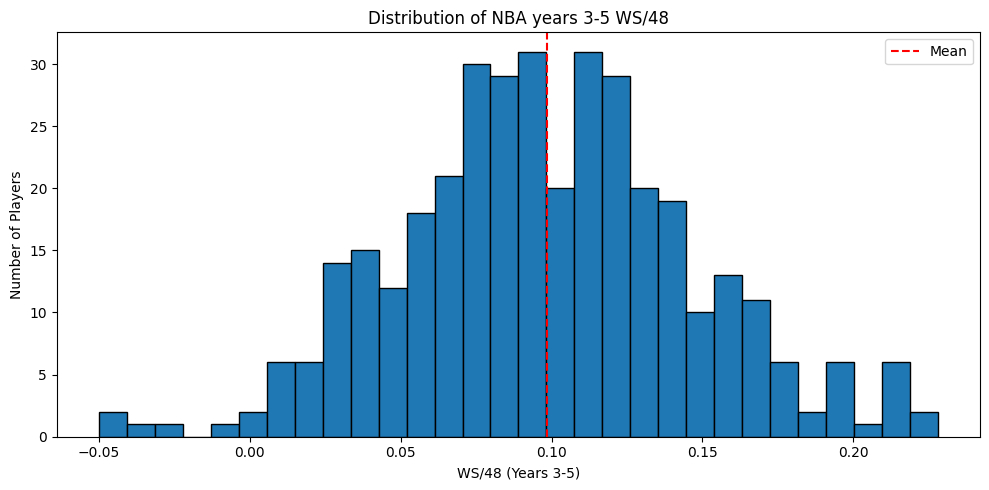

In [17]:
#what does my target variable look like?
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(modeling_df['ws48_yr3_5'],bins=30, edgecolor = 'black')
plt.axvline(modeling_df['ws48_yr3_5'].mean(),color = 'red',linestyle = '--',
            label = 'Mean')
plt.xlabel('WS/48 (Years 3-5)')
plt.ylabel('Number of Players')
plt.title('Distribution of NBA years 3-5 WS/48')
plt.legend()
plt.tight_layout()
plt.savefig(f"{PATHS['outputs']}/ws48_distribution.png")
plt.show()

In [18]:
# WS/48 Statistics & Skewness
print(modeling_df['ws48_yr3_5'].describe())

print(f"\nSkewness: {modeling_df['ws48_yr3_5'].skew():.3f}")

count    365.000000
mean       0.098363
std        0.048491
min       -0.050000
25%        0.066748
50%        0.096081
75%        0.129102
max        0.228083
Name: ws48_yr3_5, dtype: float64

Skewness: 0.063


In [19]:
Q1=modeling_df['ws48_yr3_5'].quantile(0.25)
Q3 =modeling_df['ws48_yr3_5'].quantile(0.75)

IQR = Q3 - Q1
outliers = modeling_df[
    (modeling_df['ws48_yr3_5']< Q1 - 1.5*IQR)|
    (modeling_df['ws48_yr3_5'] > Q3 + 1.5*IQR)
]

print(f"Outliers: {len(outliers)}")
print(outliers[['player_name','draft_year','draft_pick','ws48_yr3_5']])

Outliers: 4
        player_name  draft_year  draft_pick  ws48_yr3_5
74      Austin Daye        2009          15   -0.050000
88    Toney Douglas        2009          29   -0.046000
194   Kawhi Leonard        2011          15    0.228083
539  Tyrone Wallace        2016          60   -0.033558


In [20]:
#checking for missing values for all features
null_rates= modeling_df.isnull().mean().sort_values(ascending = False)
print(null_rates[null_rates > 0])

hand_width                         0.320548
hand_length                        0.320548
weight                             0.241096
body_fat_percentage                0.238356
height                             0.235616
height_with_shoes                  0.235616
standing_reach                     0.235616
wingspan                           0.232877
position                           0.210959
dunksmade/(dunksmade+dunksmiss)    0.117808
recruit_rank                       0.101370
rimmade                            0.079452
midmade/(midmade+midmiss)          0.079452
rimmade+rimmiss                    0.079452
mid_made                           0.079452
rimmade/(rimmade+rimmiss)          0.079452
dunksmiss+dunksmade                0.079452
midmade+midmiss                    0.079452
num                                0.079452
Unnamed: 64                        0.079452
dunksmade                          0.079452
pick                               0.049315
dtype: float64


In [21]:
modeling_df.columns

Index(['player_name', 'draft_year', 'draft_pick', 'draft_round', 'org_name',
       'org_type', 'player_type', 'PERSON_ID', 'total_mp_yr3_5', 'ws48_yr3_5',
       'met_minutes_threshold', 'team', 'conf', 'G', 'Min_per', 'ORtg', 'usg',
       'eFG', 'TS_pct', 'ORB_pct', 'DRB_pct', 'AST_pct', 'TO_pct', 'FTM',
       'FTA', 'FT_per', 'twoPM', 'twoPA', 'twoP_per', 'TPM', 'TPA', 'TP_per',
       'blk_pct', 'stl_per', 'ftr', 'yr', 'ht', 'num', 'porpag', 'adjoe',
       'pfr', 'season_year', 'pid', 'type', 'recruit_rank', 'ast/tov',
       'rimmade', 'rimmade+rimmiss', 'mid_made', 'midmade+midmiss',
       'rimmade/(rimmade+rimmiss)', 'midmade/(midmade+midmiss)', 'dunksmade',
       'dunksmiss+dunksmade', 'dunksmade/(dunksmade+dunksmiss)', 'pick',
       'DRtg', 'adrtg', 'dporpag', 'stops', 'BPM', 'OBPM', 'DBPM', 'gbpm',
       'mp', 'ogbpm', 'dgbpm', 'oreb', 'dreb', 'treb', 'ast', 'stl', 'blk',
       'pts', 'Unnamed: 64', 'Unnamed: 65', 'position', 'height',
       'height_with_shoes', 'wei

In [22]:
cols_to_drop = [
    'Unnamed: 64',
    'Unnamed: 65',
    'pick',
    'num',
    'pid',
    'PERSON_ID'
]

modeling_df = modeling_df.drop(columns=cols_to_drop, errors='ignore')

print(f"Shape after dropping useless columns: {modeling_df.shape}")

Shape after dropping useless columns: (365, 79)


In [23]:
# EDA - Feature selection
TARGET = 'ws48_yr3_5'

EXCLUDE = ['player_name','draft_year','draft_pick',
           'draft_round','org_name','org_type',
           'player_type','PERSON_ID','met_minutes_threshold',
           'total_mp_yr3_5','season_year', 'pid','height_with_shoes',TARGET
]

numeric_cols= modeling_df.select_dtypes(include = 'number').columns

feature_cols= [
    c for c in numeric_cols
    if c != TARGET
    and c not in EXCLUDE
    and 'unnamed' not in c.lower()
]

print(f"Total features: {len(feature_cols)}")
print(feature_cols)

Total features: 61
['G', 'Min_per', 'ORtg', 'usg', 'eFG', 'TS_pct', 'ORB_pct', 'DRB_pct', 'AST_pct', 'TO_pct', 'FTM', 'FTA', 'FT_per', 'twoPM', 'twoPA', 'twoP_per', 'TPM', 'TPA', 'TP_per', 'blk_pct', 'stl_per', 'ftr', 'porpag', 'adjoe', 'pfr', 'recruit_rank', 'ast/tov', 'rimmade', 'rimmade+rimmiss', 'mid_made', 'midmade+midmiss', 'rimmade/(rimmade+rimmiss)', 'midmade/(midmade+midmiss)', 'dunksmade', 'dunksmiss+dunksmade', 'dunksmade/(dunksmade+dunksmiss)', 'DRtg', 'adrtg', 'dporpag', 'stops', 'BPM', 'OBPM', 'DBPM', 'gbpm', 'mp', 'ogbpm', 'dgbpm', 'oreb', 'dreb', 'treb', 'ast', 'stl', 'blk', 'pts', 'height', 'weight', 'wingspan', 'standing_reach', 'body_fat_percentage', 'hand_length', 'hand_width']


In [24]:
# EDA - Handleing missing values

from sklearn.impute import SimpleImputer

X = modeling_df[feature_cols].copy()
y = modeling_df[TARGET].copy()

# fill missing values with median for each column
imputer = SimpleImputer(strategy = 'median')
X_imputed = imputer.fit_transform(X)

X = pd.DataFrame(X_imputed, columns = feature_cols)

print(f"Nulls remaining: {X.isnull().sum().sum()}")

Nulls remaining: 0


In [25]:
# EDA - Confirm shape

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (365, 61)
y shape: (365,)


In [26]:
# Train Test split

train_mask = modeling_df['draft_year'].values <= 2019
test_mask = modeling_df['draft_year'].values >= 2020

x_train=X[train_mask]
x_test=X[test_mask]

y_train= y[train_mask]
y_test=y[test_mask]

print(f"Train: {x_train.shape} | Years 2008-2019")
print(f"Test: {x_test.shape} | Years 2020-2021")

Train: (305, 61) | Years 2008-2019
Test: (60, 61) | Years 2020-2021


In [27]:
# Scaling features before LASSO
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_trained_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f" Trained scaled: {x_trained_scaled.shape}")
print(f" Test scaled: {x_test_scaled.shape}")

 Trained scaled: (305, 61)
 Test scaled: (60, 61)


Note: We call fit_transform on train and transform only on test. Never fit the scaler on test data that would leak test information into your scaling parameters.

In [28]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5,random_state=42, max_iter=10000 )
lasso.fit(x_trained_scaled, y_train)

print(f"Best alpha: {lasso.alpha_:.6f}")
print(f"Features kept: {(lasso.coef_ !=0).sum()}")
print(f"Features eliminated: {(lasso.coef_ ==0).sum()}")


Best alpha: 0.003990
Features kept: 8
Features eliminated: 53


Lasso kept 8 features as useful
Lasso shrank 53 features to zero

In [29]:
#observing which features survived the cut :

selected_features = pd.DataFrame({
    'features': feature_cols,
    'coef': lasso.coef_
})


selected_features = selected_features[selected_features['coef'] != 0].copy()

selected_features['abs_coef'] = selected_features['coef'].abs()

selected_features = selected_features.sort_values('abs_coef', ascending=False)

print(selected_features)

    features      coef  abs_coef
19   blk_pct  0.005980  0.005980
6    ORB_pct  0.004780  0.004780
5     TS_pct  0.004618  0.004618
7    DRB_pct  0.003937  0.003937
15  twoP_per  0.003766  0.003766
2       ORtg  0.001292  0.001292
40       BPM  0.001136  0.001136
21       ftr  0.000612  0.000612


In [30]:
# VIF check for Multicollinarity
from statsmodels.stats.outliers_influence import variance_inflation_factor



selected_features_vif = [
    'blk_pct','ORB_pct',
    'DRB_pct', 'twoP_per', 'ORtg',
    'BPM', 'ftr'
]

X_train_scaled_df= pd.DataFrame(x_trained_scaled, columns= feature_cols )

X_vif_check = X_train_scaled_df[selected_features_vif]


vif_data = pd.DataFrame() #starts an empty dataframe

vif_data["features"] = selected_features_vif

vif_data['VIF']=[variance_inflation_factor(X_vif_check.values, i )
for i in range(len(selected_features_vif))]

print(vif_data.sort_values('VIF', ascending=False).to_string())





   features       VIF
1   ORB_pct  2.684160
4      ORtg  2.514871
2   DRB_pct  2.347804
5       BPM  2.098164
0   blk_pct  2.075726
3  twoP_per  1.874085
6       ftr  1.247406


`TS_pct` had the highest VIF above 5, so it was removed.
After rechecking VIF, all remaining selected features were below 5. The final VIF-cleaned Lasso feature set contains 7 features.

In [31]:
# Final feature set after Lasso + VIF cleanup

selected_features_final = [
    'blk_pct',
    'ORB_pct',
    'DRB_pct',
    'twoP_per',
    'ORtg',
    'BPM',
    'ftr'
]

print(f"Final features: ({len(selected_features_final)}):{selected_features_final}")

Final features: (7):['blk_pct', 'ORB_pct', 'DRB_pct', 'twoP_per', 'ORtg', 'BPM', 'ftr']


In [32]:
# Create final train/test feature sets
X_train_final = x_train[selected_features_final]
X_test_final = x_test[selected_features_final]

print(f"Train: {X_train_final.shape}")
print(f"Test: {X_test_final.shape}")

Train: (305, 7)
Test: (60, 7)


In [33]:
# Scale final selected features
scaler_final = StandardScaler()

X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_test_final_scaled = scaler_final.transform(X_test_final)

print(f"Train scaled: {X_train_final_scaled.shape}")
print(f"Test scaled: {X_test_final_scaled.shape}")

Train scaled: (305, 7)
Test scaled: (60, 7)


# Linear Regression Model(baseline)

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

#object
base_line_model = LinearRegression()
#learn
base_line_model.fit(X_train_final_scaled, y_train)

train_preds = base_line_model.predict(X_train_final_scaled)
test_preds = base_line_model.predict(X_test_final_scaled)

print(f"Train R²: {r2_score(y_train, train_preds):.3f}")
print(f"Test R²: {r2_score(y_test, test_preds):.3f}")
print(f"Train MAE: {mean_absolute_error(y_train, train_preds):.4}")
print(f"Test MAE: {mean_absolute_error(y_test, test_preds):.4f}")

Train R²: 0.252
Test R²: 0.192
Train MAE: 0.0318
Test MAE: 0.0349


# Ridge Regression

In [35]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score

ridge_model = RidgeCV(alphas=[0.01,0.1,1,10,100,200,500,1000], cv=5)
ridge_model.fit(X_train_final_scaled, y_train)
print(f"Best alpha: {ridge_model.alpha_:.4f}")

y_pred_train_ridge = ridge_model.predict(X_train_final_scaled)
y_pred_test_ridge  = ridge_model.predict(X_test_final_scaled)

print(f"Train R²:  {r2_score(y_train, y_pred_train_ridge):.3f}")
print(f"Test R²:   {r2_score(y_test, y_pred_test_ridge):.3f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train_ridge):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred_test_ridge):.4f}")

Best alpha: 100.0000
Train R²:  0.249
Test R²:   0.194
Train MAE: 0.0320
Test MAE:  0.0346


# Random Forest

In [38]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators =500,
    max_depth = 3,
    min_samples_leaf = 15,
    random_state = 42,
    n_jobs = -1

)

rf.fit(X_train_final,y_train)
y_pred_train_rf = rf.predict(X_train_final)
y_pred_test_rf = rf.predict(X_test_final)

print(f"Train R²: {r2_score(y_train, y_pred_train_rf):.3f}")
print(f"Test R²:  {r2_score(y_test, y_pred_test_rf):.3f}")

print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train_rf):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred_test_rf):.4f}")

Train R²: 0.343
Test R²:  0.223
Train MAE: 0.0306
Test MAE:  0.0347


# GAM

In [39]:
print(f"Final features: ({len(selected_features_final)}):{selected_features_final}")

Final features: (7):['blk_pct', 'ORB_pct', 'DRB_pct', 'twoP_per', 'ORtg', 'BPM', 'ftr']


In [66]:
!pip install pygam --quiet
from pygam import LinearGAM, s, l, te
import matplotlib.pyplot as plt

selected_features_final = [
    'blk_pct',     # 0
    'ORB_pct',     # 1
    'DRB_pct',     # 2
    'twoP_per',    # 3
    'ORtg',        # 4
    'BPM',         # 5
    'ftr'          # 6
]

gam_final = LinearGAM(te(0,2) + te(3,4))

gam_final.gridsearch(X_train_final_scaled, y_train.values)
print(gam_final.summary())

100% (11 of 11) |########################| Elapsed Time: 0:00:02 Time:  0:00:02


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      7.0567
Link Function:                     IdentityLink Log Likelihood:                                   533.8287
Number of Samples:                          305 AIC:                                            -1051.5439
                                                AICc:                                           -1051.0507
                                                GCV:                                                0.0019
                                                Scale:                                              0.0425
                                                Pseudo R-Squared:                                   0.2459
Feature Function                  Lam

/tmp/ipykernel_438/3144595845.py:18: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_final.summary())


In [67]:
y_pred_train_gam = gam_final.predict(X_train_final_scaled)
y_pred_test_gam  = gam_final.predict(X_test_final_scaled)

print(f"Train R²:  {r2_score(y_train, y_pred_train_gam):.3f}")
print(f"Test R²:   {r2_score(y_test, y_pred_test_gam):.3f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train_gam):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred_test_gam):.4f}")

Train R²:  0.246
Test R²:   0.205
Train MAE: 0.0319
Test MAE:  0.0355


In [68]:
#Now run Spearman rank correlation to see if the model ranks players correctly:
from scipy.stats import spearmanr

linear_sp = spearmanr(y_test, test_preds)
ridge_sp = spearmanr(y_test, y_pred_test_ridge)
rf_sp    = spearmanr(y_test, y_pred_test_rf)
gam_sp   = spearmanr(y_test, y_pred_test_gam)


print(f"Linear Spearman: {linear_sp.statistic:.3f} (p={linear_sp.pvalue:.3f})")
print(f"Ridge Spearman: {ridge_sp.statistic:.3f} (p={ridge_sp.pvalue:.3f})")
print(f"RF Spearman:    {rf_sp.statistic:.3f} (p={rf_sp.pvalue:.3f})")
print(f"GAM Spearman:   {gam_sp.statistic:.3f} (p={gam_sp.pvalue:.3f})")

Linear Spearman: 0.367 (p=0.004)
Ridge Spearman: 0.364 (p=0.004)
RF Spearman:    0.405 (p=0.001)
GAM Spearman:   0.369 (p=0.004)


## Model Comparison

| Metric    | Linear| Ridge | RF Tuned |    GAM |
| --------- |-------|-----: | -------: | -----: |
| Train R²  | 0.252 | 0.249 |    0.343 |  0.246 |
| Test R²   | 0.192 | 0.194 |  0.0.223 |  0.205 |
| Train MAE | 0.0318|0.0320 |   0.0306 | 0.0319 |
| Test MAE  | 0.0349|0.0346 |   0.0347 | 0.0355 |
| Spearman  | 0.367 | 0.364 |    0.405 |  0.369 |
| P-value   | 0.004 | 0.004 |    0.001 |  0.004 |

**Takeaway:** Random Forest:
- Explains the most variation in unseen players.
- Has the strongest prospect-ranking ability.
- Has a Test MAE only 0.0001 worse than Ridge.
- Has a statistically significant Spearman result because p=0.001.

**For a draft tool, ranking players correctly is especially important. Therefore, Random Forest is the current winner.**



# Undervalued Players

In [69]:
def label_value(gap):
    if gap >= 5:
        return 'Undervalued'
    elif gap <= -5:
        return 'Overvalued'
    else:
        return 'Fair Value'

test_players = modeling_df[test_mask][['player_name','draft_year','draft_pick']].copy()
test_players['model_rank']      = y_pred_test_rf.argsort()[::-1].argsort() + 1
test_players['draft_model_gap'] = test_players['draft_pick'] - test_players['model_rank']
test_players['value_label']     = test_players['draft_model_gap'].apply(label_value)
test_players['predicted_ws48']  = y_pred_test_rf
test_players['actual_ws48']     = y_test.values
test_players['actual_rank']     = test_players['actual_ws48'].rank(ascending=False).astype(int)
test_players['rank_diff']       = test_players['actual_rank'] - test_players['model_rank']
print(test_players.sort_values('model_rank').head(10).to_string())

        player_name  draft_year  draft_pick  model_rank  draft_model_gap  value_label  predicted_ws48  actual_ws48  actual_rank  rank_diff
761   Nick Richards        2020          42           1               41  Undervalued        0.143424     0.150223           10          9
741      Zeke Nnaji        2020          22           2               20  Undervalued        0.141542     0.101029           31         29
725  Onyeka Okongwu        2020           6           3                3   Fair Value        0.139184     0.169948            6          3
782     Evan Mobley        2021           3           4               -1   Fair Value        0.139025     0.175137            5          1
729     Jalen Smith        2020          10           5                5  Undervalued        0.137586     0.133735           16         11
735  Isaiah Stewart        2020          16           6               10  Undervalued        0.135732     0.089519           38         32
837    Jericho Sims        

# 2026 NBA DRAFT PEEK AHEAD

In [82]:
df_2026 = pd.read_csv(f"{PATHS['raw']}/college_stats_2026.csv")
print(f"Loaded: {df_2026.shape}")
print(f"Columns: {df_2026.columns.tolist()[:10]}")

Loaded: (4087, 67)
Columns: ['player_name', 'team', 'conf', 'G', 'min_pct', 'ORtg', 'usg', 'eFG', 'TS_pct', 'ORB_pct']


In [83]:
prospects_2026 = [
    ("AJ Dybantsa", 1), ("Darryn Peterson", 2),
    ("Cameron Boozer", 3), ("Caleb Wilson", 4),
    ("Keaton Wagler", 5), ("Mikel Brown Jr.", 6),
    ("Darius Acuff Jr.", 7), ("Kingston Flemings", 8),
    ("Morez Johnson Jr.", 9), ("Brayden Burries", 10),
    ("Yaxel Lendeborg", 11), ("Aday Mara", 12),
    ("Nate Ament", 13), ("Hannes Steinbach", 14),
    ("Dailyn Swain", 15), ("Bennett Stirtz", 16),
    ("Ebuka Okorie", 17), ("Christian Anderson", 18),
    ("Allen Graves", 19), ("Jayden Quaintance", 20),
    ("Karim Lopez", 21), ("Labaron Philon Jr.", 22),
    ("Zuby Ejiofor", 23), ("Cameron Carr", 24),
    ("Sergio De Larrea", 25), ("Tarris Reed Jr.", 26),
    ("Chris Cenac Jr.", 27), ("Joshua Jefferson", 28),
    ("Alex Karaban", 29), ("Koa Peat", 30)
]

In [84]:
def label_value(gap):
    if gap >= 5:
        return 'Undervalued'
    elif gap <= -5:
        return 'Overvalued'
    else:
        return 'Fair Value'

In [85]:
# Check that all seven model features exist in the 2026 data
missing_features = [
    col for col in selected_features_final
    if col not in df_2026.columns
]

print("Missing model features:", missing_features)

Missing model features: ['twoP_per']


In [86]:
[c for c in df_2026.columns
 if "two" in c.lower() or "2p" in c.lower()]

['two_pm', 'two_pa', 'two_pct']

In [87]:
import numpy as np

df_2026["twoP_per"] = np.where(
    df_2026["two_pa"] > 0,
    df_2026["two_pm"] / df_2026["two_pa"],
    np.nan
)

In [88]:
missing_features = [
    col for col in selected_features_final
    if col not in df_2026.columns
]

print("Missing model features:", missing_features)

Missing model features: []


In [89]:
name_fixes = {
    "Labaron Philon Jr.": "Labaron Philon",
    "Chris Cenac Jr.": "Chris Cenac Jr"
}

In [90]:
results = []
missing_players = []

# Use medians from the original training data
training_medians = X_train_final.median()

for name, pick in prospects_2026:

    dataset_name = name_fixes.get(name, name)

    player = df_2026[
        df_2026["player_name"] == dataset_name
    ].copy()

    if player.empty:
        missing_players.append(name)
        continue

    # Keep the same seven features in the same order
    feature_vals = player[selected_features_final].copy()

    # Fill missing values using training-data medians
    feature_vals = feature_vals.fillna(training_medians)

    # Generate this player's Random Forest prediction
    predicted_ws48 = rf.predict(feature_vals)[0]

    results.append({
        "draft_pick": pick,
        "player_name": name,
        "predicted_ws48": round(predicted_ws48, 3),
        "vs_average": round(predicted_ws48 - 0.099, 3)
    })

In [91]:
# Rank prospects by predicted WS/48
df_results = (
    pd.DataFrame(results)
    .sort_values("predicted_ws48", ascending=False)
    .reset_index(drop=True)
)

df_results["model_rank"] = range(1, len(df_results) + 1)

df_results["draft_model_gap"] = (
    df_results["draft_pick"] - df_results["model_rank"]
)

df_results["value_label"] = (
    df_results["draft_model_gap"].apply(label_value)
)

print(
    df_results[
        [
            "player_name",
            "draft_pick",
            "model_rank",
            "draft_model_gap",
            "value_label",
            "predicted_ws48",
            "vs_average"
        ]
    ].to_string(index=False)
)

print("\nPlayers not found:")
print(missing_players)

       player_name  draft_pick  model_rank  draft_model_gap value_label  predicted_ws48  vs_average
    Cameron Boozer           3           1                2  Fair Value           0.142       0.043
 Morez Johnson Jr.           9           2                7 Undervalued           0.137       0.038
      Caleb Wilson           4           3                1  Fair Value           0.137       0.038
      Zuby Ejiofor          23           4               19 Undervalued           0.137       0.038
   Tarris Reed Jr.          26           5               21 Undervalued           0.136       0.037
  Hannes Steinbach          14           6                8 Undervalued           0.134       0.035
         Aday Mara          12           7                5 Undervalued           0.131       0.032
      Allen Graves          19           8               11 Undervalued           0.131       0.032
      Dailyn Swain          15           9                6 Undervalued           0.116       0.017


## 2026 Draft Board — How to Read This Table

### What Each Column Means

**draft_pick** — the player’s projected draft position entered in the `prospects_2026` list.

**model_rank** — where the Random Forest model ranks the player based on the seven selected college features:

* Block percentage
* Offensive rebound percentage
* Defensive rebound percentage
* Two-point percentage
* Offensive rating
* Box Plus/Minus
* Free-throw rate

**draft_model_gap** — the difference between the projected draft pick and model rank.

* A positive number means the model ranks the player higher than the projected draft position.
* A negative number means the projected draft position ranks the player higher than the model.

**value_label** — a simple summary of the ranking difference:

* **Undervalued:** model ranks the player at least five spots higher
* **Overvalued:** model ranks the player at least five spots lower
* **Fair Value:** projected pick and model rank are within four spots

**predicted_ws48** — the Random Forest model’s prediction for the player’s NBA Win Shares per 48 minutes during Years 3–5.

The comparison benchmark used in this project is:

```python
0.099 WS/48
```

**vs_average** — how far above or below the `0.099` benchmark the player is predicted to perform.

* Positive = above average
* Negative = below average
* Zero = approximately average

---

### Highest-Ranked Prospects

The model’s top five prospects were:

1. Cameron Boozer — predicted WS/48 of `0.142`
2. Morez Johnson Jr. — predicted WS/48 of `0.137`
3. Caleb Wilson — predicted WS/48 of `0.137`
4. Zuby Ejiofor — predicted WS/48 of `0.137`
5. Tarris Reed Jr. — predicted WS/48 of `0.136`

Cameron Boozer was the model’s top prospect and was predicted to perform `0.043` WS/48 above the project benchmark.

---

### Potential Draft Steals

**Tarris Reed Jr.**

* Projected pick: 26
* Model rank: 5
* Ranking gap: +21
* Predicted WS/48: `0.136`

**Zuby Ejiofor**

* Projected pick: 23
* Model rank: 4
* Ranking gap: +19
* Predicted WS/48: `0.137`

**Joshua Jefferson**

* Projected pick: 28
* Model rank: 13
* Ranking gap: +15
* Predicted WS/48: `0.096`

Other prospects identified as potentially undervalued include Cameron Carr, Alex Karaban, Allen Graves, Koa Peat, Hannes Steinbach, Morez Johnson Jr., Dailyn Swain, and Aday Mara.

These players should be monitored to determine whether they outperform their projected draft positions during NBA Years 3–5.

---

### Potentially Overvalued Prospects

**Darryn Peterson**

* Projected pick: 2
* Model rank: 25
* Ranking gap: -23
* Predicted WS/48: `0.067`

**Keaton Wagler**

* Projected pick: 5
* Model rank: 24
* Ranking gap: -19
* Predicted WS/48: `0.070`

**Mikel Brown Jr.**

* Projected pick: 6
* Model rank: 21
* Ranking gap: -15
* Predicted WS/48: `0.078`

**Darius Acuff Jr.**

* Projected pick: 7
* Model rank: 22
* Ranking gap: -15
* Predicted WS/48: `0.077`

The model also ranked AJ Dybantsa, Kingston Flemings, and Nate Ament substantially below their projected draft positions.

This does not mean these players will fail. It means their current college statistical profiles do not score as highly using the specific features learned by this model.

---

### Players Missing From the Initial Board

The initial results included predictions for 25 of the 30 listed prospects.

The following players were not matched:

* Jayden Quaintance
* Karim Lopez
* Sergio De Larrea

Karim Lopez and Sergio De Larrea did not play college basketball, so they cannot be evaluated directly by this college-statistics model.

Jayden Quaintance was not available in the specific 2026 college dataset used for these predictions.

---

### Important Caveat

This model was trained using college players and rewards statistical profiles associated with:

* Interior efficiency
* Rebounding
* Shot blocking
* Overall box-score impact
* Free-throw generation

It does not directly measure several important scouting factors, including:

* Age and development potential
* Athleticism
* Defensive versatility
* Perimeter shot creation
* Passing creativity
* Combine measurements not included in the final model
* International professional-league performance
* Team role and system fit
* Medical or injury information

The Random Forest should therefore be used as a decision-support tool alongside scouting, film evaluation, medical information, and player-development projections—not as the final answer on a prospect.


In [94]:
import joblib
import os

os.makedirs(PATHS["outputs"], exist_ok=True)
os.makedirs(PATHS["processed"], exist_ok=True)

# Save final Random Forest model
joblib.dump(rf, f"{PATHS['outputs']}/rf_model.pkl")

# Save preprocessing information
joblib.dump(
    selected_features_final,
    f"{PATHS['outputs']}/selected_features.pkl"
)

joblib.dump(
    training_medians,
    f"{PATHS['outputs']}/training_medians.pkl"
)

# Save 2026 draft board
df_results.to_csv(
    f"{PATHS['processed']}/draft_board_2026.csv",
    index=False
)

print("Random Forest model saved.")
print(f"Features saved: {selected_features_final}")
print("Training medians saved.")
print("Draft board saved.")

Random Forest model saved.
Features saved: ['blk_pct', 'ORB_pct', 'DRB_pct', 'twoP_per', 'ORtg', 'BPM', 'ftr']
Training medians saved.
Draft board saved.
